#Problem Statement

Delhivery, as a leading logistics company, generates a massive amount of raw data from its daily operations. However, this data is currently messy, spread across multiple rows for a single delivery, and difficult to use directly. The main challenge is transforming this complex, raw logistics data into clean, meaningful, and predictive features. We need to organize the data, figure out how to combine delivery segments into complete trip records, and extract crucial information—like trip duration, route details, and timing features—so that the data science team can build accurate forecasting models to optimize our routes and delivery times.

#Basic Metrics

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
df=pd.read_csv('delhivery_data.csv')

In [172]:
#shape of the data
df.shape

(144867, 24)

In [173]:
#first five rows of the dataframe
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [174]:
#columns in the data
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'],
      dtype='object')

In [175]:
#datatypes of columns
df.dtypes

,0
data,object
trip_creation_time,object
route_schedule_uuid,object
route_type,object
trip_uuid,object
source_center,object
source_name,object
destination_center,object
destination_name,object
od_start_time,object


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [177]:
#conversion of categorical variables into category
df['data']=df['data'].astype('category')
df['route_type']=df['route_type'].astype('category')
df['source_name']=df['source_name'].astype('category')
df['destination_name']=df['destination_name'].astype('category')


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   data                            144867 non-null  category
 1   trip_creation_time              144867 non-null  object  
 2   route_schedule_uuid             144867 non-null  object  
 3   route_type                      144867 non-null  category
 4   trip_uuid                       144867 non-null  object  
 5   source_center                   144867 non-null  object  
 6   source_name                     144574 non-null  category
 7   destination_center              144867 non-null  object  
 8   destination_name                144606 non-null  category
 9   od_start_time                   144867 non-null  object  
 10  od_end_time                     144867 non-null  object  
 11  start_scan_to_end_scan          144867 non-null  float64 
 12  is

In [179]:
#missing values
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


There are missing values only in the source name and destination name columns.

Dropping all the rows with missing values.

In [180]:
#Handle missing values in the data.
df.dropna(inplace=True)

In [181]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,0
destination_center,0
destination_name,0
od_start_time,0


All the rows with missing values are dropped.

In [182]:
#statistical summary
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000
mean,963.697698,233.561345,234.708498,417.996237,214.437055,285.549785,2.120178,36.175379,18.495697,22.818993,2.218707
std,1038.082976,345.245823,345.480571,598.940065,308.448543,421.717826,1.717065,53.524298,14.774008,17.866367,4.854804
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.000000,-23.444444
25%,161.000000,22.000000,23.352027,51.000000,27.000000,29.896250,1.604545,20.000000,11.000000,12.053975,1.347826
50%,451.000000,66.000000,66.135322,132.000000,64.000000,78.624400,1.857143,28.000000,17.000000,23.508300,1.684211
75%,1645.000000,286.000000,286.919294,516.000000,259.000000,346.305400,2.212280,40.000000,22.000000,27.813325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.403700,574.250000


In [183]:
#Converting time columns into pandas datetime.
df['trip_creation_time']=pd.to_datetime(df['trip_creation_time'],format='mixed')
df['od_start_time']=pd.to_datetime(df['od_start_time'],format='mixed')
df['od_end_time']=pd.to_datetime(df['od_end_time'],format='mixed')

Grouping by segment

In [184]:
#combining the trip_uuid, source_center, and destination_center and naming it as segment_key.
df['segment_key'] = df['trip_uuid'].astype(str) + '_' + df['source_center'].astype(str) + '_' + df['destination_center'].astype(str)
print("New column 'segment_key' created.")
df[['trip_uuid', 'source_center', 'destination_center', 'segment_key']].head()

New column 'segment_key' created.


,trip_uuid,source_center,destination_center,segment_key
0,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
1,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
2,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
3,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
4,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB


To merge rows and aggregate the `segment_actual_time`, `segment_osrm_distance`, and `segment_osrm_time` columns based on the `segment_key`, I will use `groupby()` on `segment_key` and then apply `cumsum()` to these columns. This will create a running total for each segment, effectively merging the values within each segment.

In [185]:
df['segment_actual_time_sum'] = df.groupby(['segment_key'])['segment_actual_time'].cumsum()
df['segment_osrm_distance_sum'] = df.groupby(['segment_key'])['segment_osrm_distance'].cumsum()
df['segment_osrm_time_sum'] = df.groupby(['segment_key'])['segment_osrm_time'].cumsum()
df[['segment_key', 'segment_actual_time', 'segment_actual_time_sum', 'segment_osrm_distance', 'segment_osrm_distance_sum', 'segment_osrm_time', 'segment_osrm_time_sum']].head(10)

,segment_key,segment_actual_time,segment_actual_time_sum,segment_osrm_distance,segment_osrm_distance_sum,segment_osrm_time,segment_osrm_time_sum
0,trip-153741093647649320_IND388121AAA_IND388620AAB,14.0,14.0,11.9653,11.9653,11.0,11.0
1,trip-153741093647649320_IND388121AAA_IND388620AAB,10.0,24.0,9.7590,21.7243,9.0,20.0
2,trip-153741093647649320_IND388121AAA_IND388620AAB,16.0,40.0,10.8152,32.5395,7.0,27.0
3,trip-153741093647649320_IND388121AAA_IND388620AAB,21.0,61.0,13.0224,45.5619,12.0,39.0
4,trip-153741093647649320_IND388121AAA_IND388620AAB,6.0,67.0,3.9153,49.4772,5.0,44.0
5,trip-153741093647649320_IND388620AAB_IND388320AAA,15.0,15.0,12.1171,12.1171,11.0,11.0
6,trip-153741093647649320_IND388620AAB_IND388320AAA,28.0,43.0,9.1719,21.2890,6.0,17.0
7,trip-153741093647649320_IND388620AAB_IND388320AAA,21.0,64.0,14.5362,35.8252,11.0,28.0
8,trip-153741093647649320_IND388620AAB_IND388320AAA,10.0,74.0,11.3648,47.1900,10.0,38.0
9,trip-153741093647649320_IND388620AAB_IND388320AAA,26.0,100.0,6.0434,53.2334,6.0,44.0


Aggregating at segment level

In [186]:
create_segment_dict = {
    'data': 'first',
    'trip_creation_time': 'first',
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'trip_uuid': 'first',
    'source_center': 'first',
    'source_name': 'first',
    'destination_center': 'last',
    'destination_name': 'last',
    'od_start_time': 'first',
    'od_end_time': 'last',
    'start_scan_to_end_scan': 'last',
    'is_cutoff': 'last',
    'cutoff_factor': 'last',
    'cutoff_timestamp': 'last',
    'actual_distance_to_destination': 'last',
    'actual_time': 'last',
    'osrm_time': 'last',
    'osrm_distance': 'last',
    'factor': 'last',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'segment_factor': 'last',
    'segment_actual_time_sum': 'last',
    'segment_osrm_distance_sum': 'last',
    'segment_osrm_time_sum': 'last'
}

create_segment_dict

{'data': 'first',
 'trip_creation_time': 'first',
 'route_schedule_uuid': 'first',
 'route_type': 'first',
 'trip_uuid': 'first',
 'source_center': 'first',
 'source_name': 'first',
 'destination_center': 'last',
 'destination_name': 'last',
 'od_start_time': 'first',
 'od_end_time': 'last',
 'start_scan_to_end_scan': 'last',
 'is_cutoff': 'last',
 'cutoff_factor': 'last',
 'cutoff_timestamp': 'last',
 'actual_distance_to_destination': 'last',
 'actual_time': 'last',
 'osrm_time': 'last',
 'osrm_distance': 'last',
 'factor': 'last',
 'segment_actual_time': 'sum',
 'segment_osrm_time': 'sum',
 'segment_osrm_distance': 'sum',
 'segment_factor': 'last',
 'segment_actual_time_sum': 'last',
 'segment_osrm_distance_sum': 'last',
 'segment_osrm_time_sum': 'last'}

In [187]:
segment_df = df.groupby(['segment_key']).agg(create_segment_dict)

print("DataFrame aggregated by 'segment_key' using 'create_segment_dict'.")
segment_df.head()

DataFrame aggregated by 'segment_key' using 'create_segment_dict'.


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
segment_key,,,,,,,,,,,,,,,,,,,,,
trip-153671041653548748_IND209304AAA_IND000000ACB,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,329.0,446.5496,2.224924,728.0,534.0,670.6205,2.000000,728.0,670.6205,534.0
trip-153671041653548748_IND462022AAA_IND209304AAA,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,...,388.0,544.8027,2.139175,820.0,474.0,649.8528,7.333333,820.0,649.8528,474.0
trip-153671042288605164_IND561203AAB_IND562101AAA,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 02:03:09.655591,...,26.0,28.1994,1.807692,46.0,26.0,28.1995,2.142857,46.0,28.1995,26.0
trip-153671042288605164_IND572101AAA_IND561203AAB,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,...,42.0,56.9116,2.285714,95.0,39.0,55.9899,6.666667,95.0,55.9899,39.0
trip-153671043369099517_IND000000ACB_IND160002AAC,training,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,trip-153671043369099517,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2018-09-14 03:40:17.106733,...,212.0,281.2109,2.882075,608.0,231.0,317.7408,9.821429,608.0,317.7408,231.0


The aggregation functions specified in the create_segment_dict are
applied to each group of rows with the same segment_key.

To ensure that segments are consistently ordered first by segment_key and then by od_end_time, I will use the sort_values() method. This will reorder the DataFrame so that segments belonging to the same trip are grouped together and then chronologically ordered by their end times.

In [188]:
segment_df = segment_df.sort_values(by=['segment_key', 'od_end_time'], ascending=[True, True])

print("DataFrame 'segment_df' sorted by 'segment_key' and 'od_end_time'.")
segment_df.head()

DataFrame 'segment_df' sorted by 'segment_key' and 'od_end_time'.


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
segment_key,,,,,,,,,,,,,,,,,,,,,
trip-153671041653548748_IND209304AAA_IND000000ACB,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,329.0,446.5496,2.224924,728.0,534.0,670.6205,2.000000,728.0,670.6205,534.0
trip-153671041653548748_IND462022AAA_IND209304AAA,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,...,388.0,544.8027,2.139175,820.0,474.0,649.8528,7.333333,820.0,649.8528,474.0
trip-153671042288605164_IND561203AAB_IND562101AAA,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 02:03:09.655591,...,26.0,28.1994,1.807692,46.0,26.0,28.1995,2.142857,46.0,28.1995,26.0
trip-153671042288605164_IND572101AAA_IND561203AAB,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,...,42.0,56.9116,2.285714,95.0,39.0,55.9899,6.666667,95.0,55.9899,39.0
trip-153671043369099517_IND000000ACB_IND160002AAC,training,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,trip-153671043369099517,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2018-09-14 03:40:17.106733,...,212.0,281.2109,2.882075,608.0,231.0,317.7408,9.821429,608.0,317.7408,231.0


#Feature Engineering

In [189]:
segment_df['od_time_diff_hour'] = (segment_df['od_end_time'] - segment_df['od_start_time']) / np.timedelta64(1, 'h')

segment_df.drop(columns=['od_start_time', 'od_end_time'], inplace=True)

print("New feature 'od_time_diff_hour' created and original 'od_start_time', 'od_end_time' columns dropped.")
segment_df[['od_time_diff_hour']].head()

New feature 'od_time_diff_hour' created and original 'od_start_time', 'od_end_time' columns dropped.


,od_time_diff_hour
segment_key,
trip-153671041653548748_IND209304AAA_IND000000ACB,21.010074
trip-153671041653548748_IND462022AAA_IND209304AAA,16.658423
trip-153671042288605164_IND561203AAB_IND562101AAA,0.980540
trip-153671042288605164_IND572101AAA_IND561203AAB,2.046325
trip-153671043369099517_IND000000ACB_IND160002AAC,13.910649


The od_time_diff_hour feature has been successfully created, and the od_start_time and od_end_time columns have been dropped.

The destination_name column contains concatenated information: City-place-code (State). To extract these distinct features, I will use regular expressions to first isolate the state information within parentheses. Then, I will clean the destination_name column by removing the extracted state and parentheses. Finally, I will split the cleaned destination_name by the hyphen (-) to extract the city, place, and code into separate columns.

In [190]:
segment_df['destination_state'] = segment_df['destination_name'].str.extract(r'\((.*?)\)')

print("New column 'destination_state' created with extracted state information.")
segment_df[['destination_name', 'destination_state']].head()

New column 'destination_state' created with extracted state information.


,destination_name,destination_state
segment_key,,
trip-153671041653548748_IND209304AAA_IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),Haryana
trip-153671041653548748_IND462022AAA_IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),Uttar Pradesh
trip-153671042288605164_IND561203AAB_IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),Karnataka
trip-153671042288605164_IND572101AAA_IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),Karnataka
trip-153671043369099517_IND000000ACB_IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),Punjab


In [191]:
segment_df['destination_name'] = segment_df['destination_name'].str.replace(r'\s*\(.*?\)', '', regex=True)

print("Cleaned 'destination_name' by removing state information.")
segment_df[['destination_name', 'destination_state']].head()

Cleaned 'destination_name' by removing state information.


,destination_name,destination_state
segment_key,,
trip-153671041653548748_IND209304AAA_IND000000ACB,Gurgaon_Bilaspur_HB,Haryana
trip-153671041653548748_IND462022AAA_IND209304AAA,Kanpur_Central_H_6,Uttar Pradesh
trip-153671042288605164_IND561203AAB_IND562101AAA,Chikblapur_ShntiSgr_D,Karnataka
trip-153671042288605164_IND572101AAA_IND561203AAB,Doddablpur_ChikaDPP_D,Karnataka
trip-153671043369099517_IND000000ACB_IND160002AAC,Chandigarh_Mehmdpur_H,Punjab


In [192]:
split_parts = segment_df['destination_name'].str.split('_', expand=True)
segment_df['destination_city'] = split_parts[0]
segment_df['destination_place'] = split_parts[1]
segment_df['destination_code'] = split_parts[2]

segment_df.drop(columns=['destination_name'], inplace=True)

print("Cleaned 'destination_name' split into 'destination_city', 'destination_place', and 'destination_code', and original column dropped.")
segment_df[['destination_city', 'destination_place', 'destination_code', 'destination_state']].head()

Cleaned 'destination_name' split into 'destination_city', 'destination_place', and 'destination_code', and original column dropped.


,destination_city,destination_place,destination_code,destination_state
segment_key,,,,
trip-153671041653548748_IND209304AAA_IND000000ACB,Gurgaon,Bilaspur,HB,Haryana
trip-153671041653548748_IND462022AAA_IND209304AAA,Kanpur,Central,H,Uttar Pradesh
trip-153671042288605164_IND561203AAB_IND562101AAA,Chikblapur,ShntiSgr,D,Karnataka
trip-153671042288605164_IND572101AAA_IND561203AAB,Doddablpur,ChikaDPP,D,Karnataka
trip-153671043369099517_IND000000ACB_IND160002AAC,Chandigarh,Mehmdpur,H,Punjab


The source_name column contains concatenated information: City-place-code (State). To extract these distinct features, I will use regular expressions to first isolate the state information within parentheses. Then, I will clean the destination_name column by removing the extracted state and parentheses. Finally, I will split the cleaned destination_name by the hyphen (-) to extract the city, place, and code into separate columns.

In [193]:
segment_df['source_state'] = segment_df['source_name'].str.extract(r'\((.*?)\)')

print("New column 'source_state' created with extracted state information.")
segment_df[['source_name', 'source_state']].head()

New column 'source_state' created with extracted state information.


,source_name,source_state
segment_key,,
trip-153671041653548748_IND209304AAA_IND000000ACB,Kanpur_Central_H_6 (Uttar Pradesh),Uttar Pradesh
trip-153671041653548748_IND462022AAA_IND209304AAA,Bhopal_Trnsport_H (Madhya Pradesh),Madhya Pradesh
trip-153671042288605164_IND561203AAB_IND562101AAA,Doddablpur_ChikaDPP_D (Karnataka),Karnataka
trip-153671042288605164_IND572101AAA_IND561203AAB,Tumkur_Veersagr_I (Karnataka),Karnataka
trip-153671043369099517_IND000000ACB_IND160002AAC,Gurgaon_Bilaspur_HB (Haryana),Haryana


In [194]:
segment_df['source_name'] = segment_df['source_name'].str.replace(r'\s*\(.*\)', '', regex=True)

print("Cleaned 'source_name' by removing state information.")
segment_df[['source_name', 'source_state']].head()

Cleaned 'source_name' by removing state information.


,source_name,source_state
segment_key,,
trip-153671041653548748_IND209304AAA_IND000000ACB,Kanpur_Central_H_6,Uttar Pradesh
trip-153671041653548748_IND462022AAA_IND209304AAA,Bhopal_Trnsport_H,Madhya Pradesh
trip-153671042288605164_IND561203AAB_IND562101AAA,Doddablpur_ChikaDPP_D,Karnataka
trip-153671042288605164_IND572101AAA_IND561203AAB,Tumkur_Veersagr_I,Karnataka
trip-153671043369099517_IND000000ACB_IND160002AAC,Gurgaon_Bilaspur_HB,Haryana


In [195]:
split_parts_source = segment_df['source_name'].str.split('_', expand=True)
segment_df['source_city'] = split_parts_source[0]
segment_df['source_place'] = split_parts_source[1]
segment_df['source_code'] = split_parts_source[2]

segment_df.drop(columns=['source_name'], inplace=True)

print("Cleaned 'source_name' split into 'source_city', 'source_place', and 'source_code', and original column dropped.")
segment_df[['source_city', 'source_place', 'source_code', 'source_state']].head()

Cleaned 'source_name' split into 'source_city', 'source_place', and 'source_code', and original column dropped.


,source_city,source_place,source_code,source_state
segment_key,,,,
trip-153671041653548748_IND209304AAA_IND000000ACB,Kanpur,Central,H,Uttar Pradesh
trip-153671041653548748_IND462022AAA_IND209304AAA,Bhopal,Trnsport,H,Madhya Pradesh
trip-153671042288605164_IND561203AAB_IND562101AAA,Doddablpur,ChikaDPP,D,Karnataka
trip-153671042288605164_IND572101AAA_IND561203AAB,Tumkur,Veersagr,I,Karnataka
trip-153671043369099517_IND000000ACB_IND160002AAC,Gurgaon,Bilaspur,HB,Haryana


 extract the month, year, and day from the trip_creation_time column and add them as new features to the segment_df DataFrame.

In [196]:
segment_df['trip_creation_month'] = segment_df['trip_creation_time'].dt.month
segment_df['trip_creation_year'] = segment_df['trip_creation_time'].dt.year
segment_df['trip_creation_day'] = segment_df['trip_creation_time'].dt.day

print("New features 'trip_creation_month', 'trip_creation_year', and 'trip_creation_day' created.")
segment_df[['trip_creation_time', 'trip_creation_month', 'trip_creation_year', 'trip_creation_day']].head()

New features 'trip_creation_month', 'trip_creation_year', and 'trip_creation_day' created.


,trip_creation_time,trip_creation_month,trip_creation_year,trip_creation_day
segment_key,,,,
trip-153671041653548748_IND209304AAA_IND000000ACB,2018-09-12 00:00:16.535741,9,2018,12
trip-153671041653548748_IND462022AAA_IND209304AAA,2018-09-12 00:00:16.535741,9,2018,12
trip-153671042288605164_IND561203AAB_IND562101AAA,2018-09-12 00:00:22.886430,9,2018,12
trip-153671042288605164_IND572101AAA_IND561203AAB,2018-09-12 00:00:22.886430,9,2018,12
trip-153671043369099517_IND000000ACB_IND160002AAC,2018-09-12 00:00:33.691250,9,2018,12


To aggregate the data at the trip level, I need to define a dictionary (`create_trip_dict`) specifying how each column should be aggregated when grouping by `trip_uuid`. For identifying features like `trip_creation_time` and `source_center`, `first` is used. For final states like `destination_center` or `actual_distance_to_destination`, `last` is appropriate. For cumulative measures across the trip, such as `segment_actual_time`, `segment_osrm_time`, `segment_osrm_distance`, and `od_time_diff_hour`, the `sum` aggregation will be used. The cumulative sum columns (`segment_actual_time_sum`, etc.) from the segment level will also use `last` to capture the final total for the trip.

In [197]:
create_trip_dict = {
    'data': 'first',
    'trip_creation_time': 'first',
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'source_center': 'first',
    'source_city': 'first',
    'source_place': 'first',
    'source_code': 'first',
    'source_state': 'first',
    'destination_center': 'last',
    'destination_city': 'last',
    'destination_place': 'last',
    'destination_code_state': 'last',
    'is_cutoff': 'last',
    'cutoff_factor': 'last',
    'cutoff_timestamp': 'last',
    'actual_distance_to_destination': 'last',
    'actual_time': 'last',
    'osrm_time': 'last',
    'osrm_distance': 'last',
    'factor': 'last',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'segment_factor': 'last',
    'segment_actual_time_sum': 'last',
    'segment_osrm_distance_sum': 'last',
    'segment_osrm_time_sum': 'last',
    'od_time_diff_hour': 'sum',
    'trip_creation_month': 'first',
    'trip_creation_year': 'first',
    'trip_creation_day': 'first'
}

print("Dictionary 'create_trip_dict' created successfully.")
create_trip_dict


Dictionary 'create_trip_dict' created successfully.


{'data': 'first',
 'trip_creation_time': 'first',
 'route_schedule_uuid': 'first',
 'route_type': 'first',
 'source_center': 'first',
 'source_city': 'first',
 'source_place': 'first',
 'source_code': 'first',
 'source_state': 'first',
 'destination_center': 'last',
 'destination_city': 'last',
 'destination_place': 'last',
 'destination_code_state': 'last',
 'is_cutoff': 'last',
 'cutoff_factor': 'last',
 'cutoff_timestamp': 'last',
 'actual_distance_to_destination': 'last',
 'actual_time': 'last',
 'osrm_time': 'last',
 'osrm_distance': 'last',
 'factor': 'last',
 'segment_actual_time': 'sum',
 'segment_osrm_time': 'sum',
 'segment_osrm_distance': 'sum',
 'segment_factor': 'last',
 'segment_actual_time_sum': 'last',
 'segment_osrm_distance_sum': 'last',
 'segment_osrm_time_sum': 'last',
 'od_time_diff_hour': 'sum',
 'trip_creation_month': 'first',
 'trip_creation_year': 'first',
 'trip_creation_day': 'first'}

the `create_trip_dict` is defined with the appropriate aggregation functions, I will apply these rules to the `segment_df`. Grouping by `trip_uuid` and then using the `agg()` method with `create_trip_dict` will produce a new DataFrame, `trip_df`, where each row represents a unique trip with all relevant information aggregated from its constituent segments. The first few rows of `trip_df` will be displayed to verify the aggregation.

In [198]:
# Create destination_code_state in segment_df before aggregation
segment_df['destination_code_state'] = segment_df['destination_code'] + ' (' + segment_df['destination_state'] + ')'


create_trip_dict_adjusted = create_trip_dict.copy()
create_trip_dict_adjusted.pop('destination_code', None)
create_trip_dict_adjusted.pop('destination_state', None)

trip_df = segment_df.groupby(['trip_uuid']).agg(create_trip_dict_adjusted)

print("DataFrame 'trip_df' aggregated by 'trip_uuid' using 'create_trip_dict'.")
trip_df.head()

DataFrame 'trip_df' aggregated by 'trip_uuid' using 'create_trip_dict'.


,data,trip_creation_time,route_schedule_uuid,route_type,source_center,source_city,source_place,source_code,source_state,destination_center,...,segment_osrm_time,segment_osrm_distance,segment_factor,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum,od_time_diff_hour,trip_creation_month,trip_creation_year,trip_creation_day
trip_uuid,,,,,,,,,,,,,,,,,,,,,
trip-153671041653548748,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND209304AAA,Kanpur,Central,H,Uttar Pradesh,IND209304AAA,...,1008.0,1320.4733,7.333333,820.0,649.8528,474.0,37.668497,9,2018,12
trip-153671042288605164,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND561203AAB,Doddablpur,ChikaDPP,D,Karnataka,IND561203AAB,...,65.0,84.1894,6.666667,95.0,55.9899,39.0,3.026865,9,2018,12
trip-153671043369099517,training,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND000000ACB,Gurgaon,Bilaspur,HB,Haryana,IND000000ACB,...,1941.0,2545.2678,1.615385,2700.0,2227.5270,1710.0,65.572709,9,2018,12
trip-153671046011330457,training,2018-09-12 00:01:00.113710,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,Mumbai Hub,None,None,Maharashtra,IND401104AAA,...,16.0,19.8766,5.142857,59.0,19.8766,16.0,1.674916,9,2018,12
trip-153671052974046625,training,2018-09-12 00:02:09.740725,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,Bellary,Dc,D,Karnataka,IND583119AAA,...,115.0,146.7919,5.800000,63.0,29.5697,26.0,11.972484,9,2018,12


##Outlier detection and treatment

Using IQR method

In [199]:
# Select numerical columns for outlier detection
numerical_cols = trip_df.select_dtypes(include=['float64', 'int64']).columns

# Function to detect outliers using IQR method
def find_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

outliers_count = {}
for col in numerical_cols:
    outliers = find_iqr_outliers(trip_df[col])
    if not outliers.empty:
        outliers_count[col] = len(outliers)

if outliers_count:
    print("Outliers detected in the following numerical features (count):")
    for col, count in outliers_count.items():
        print(f"- {col}: {count}")
else:
    print("No significant outliers detected in numerical features using the IQR method.")

Outliers detected in the following numerical features (count):
- cutoff_factor: 2124
- actual_distance_to_destination: 2127
- actual_time: 1858
- osrm_time: 1859
- osrm_distance: 1932
- factor: 1321
- segment_actual_time: 1644
- segment_osrm_time: 1485
- segment_osrm_distance: 1550
- segment_factor: 1680
- segment_actual_time_sum: 1863
- segment_osrm_distance_sum: 1945
- segment_osrm_time_sum: 2013
- od_time_diff_hour: 1275


Using Boxplot

Generating boxplots for features with outliers:


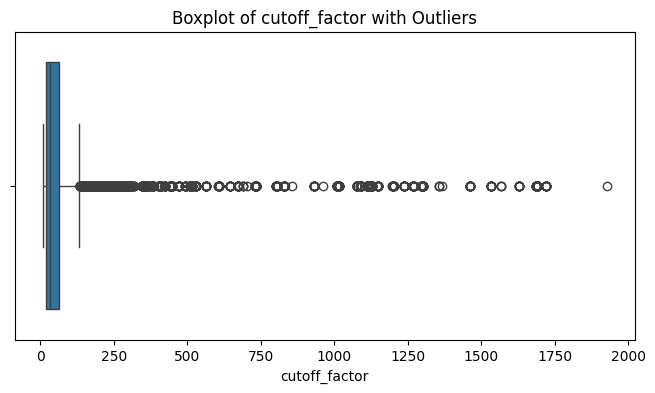

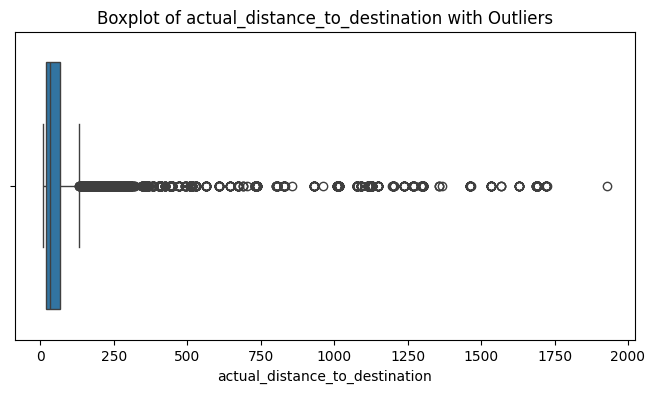

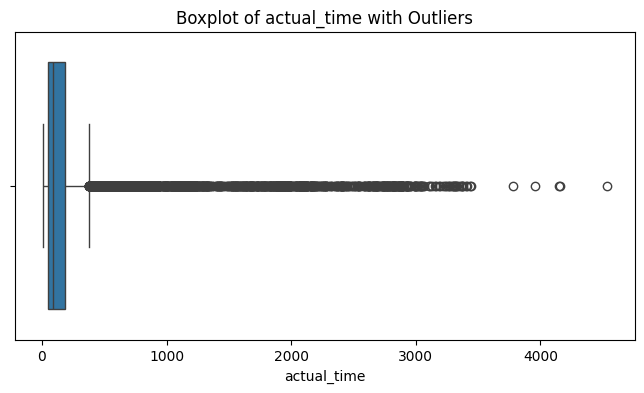

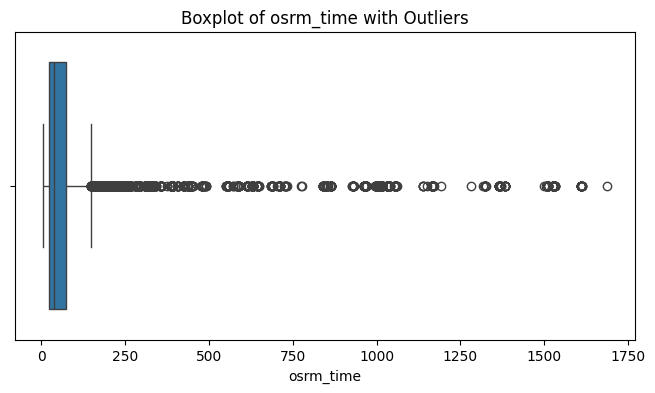

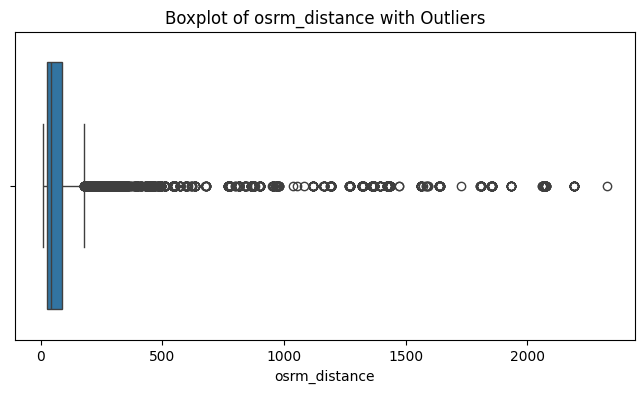

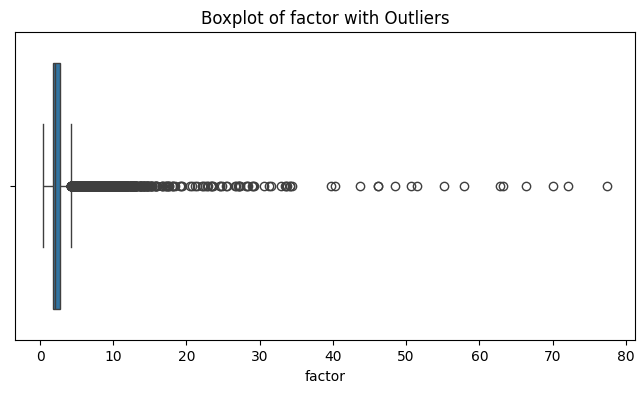

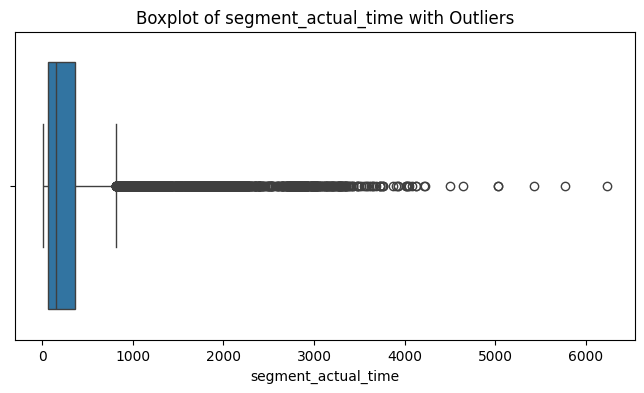

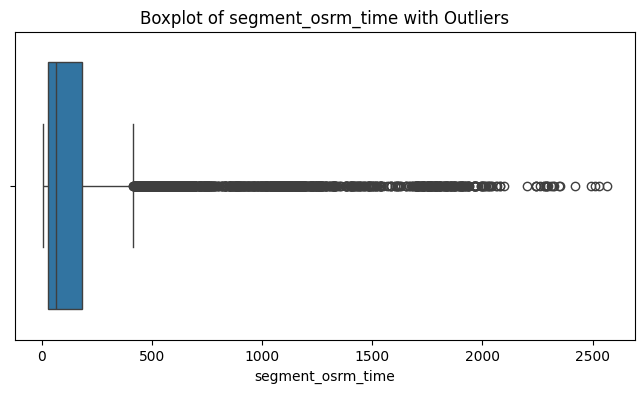

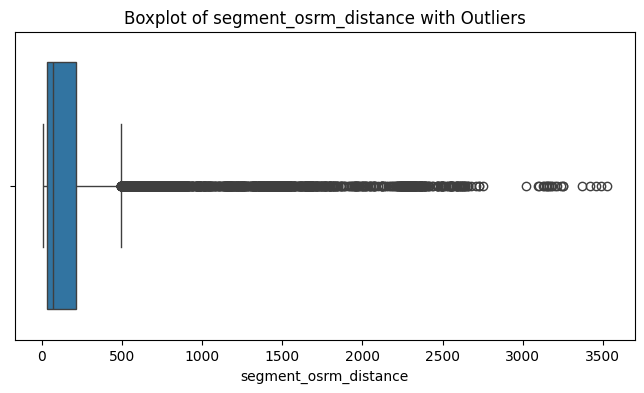

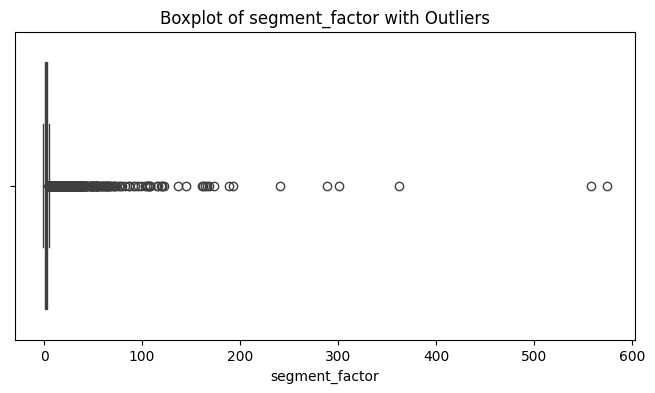

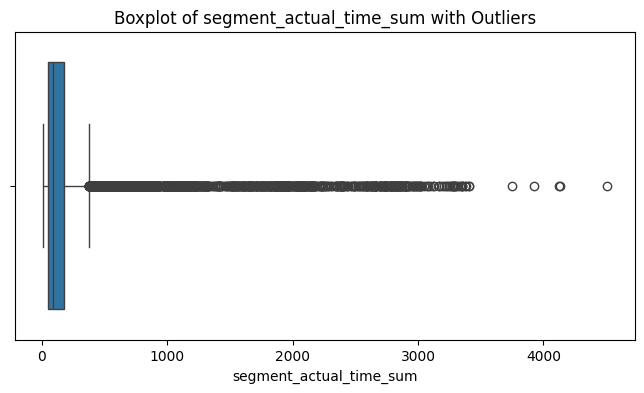

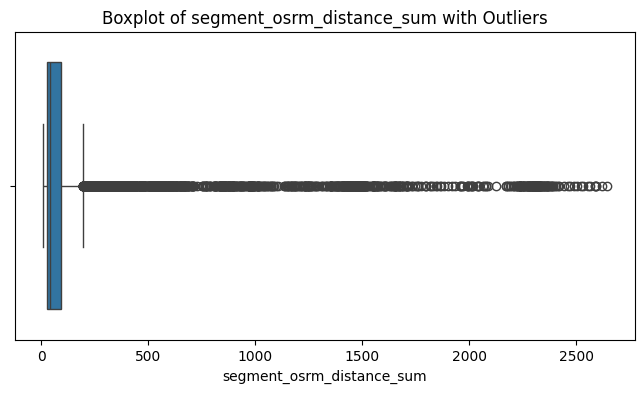

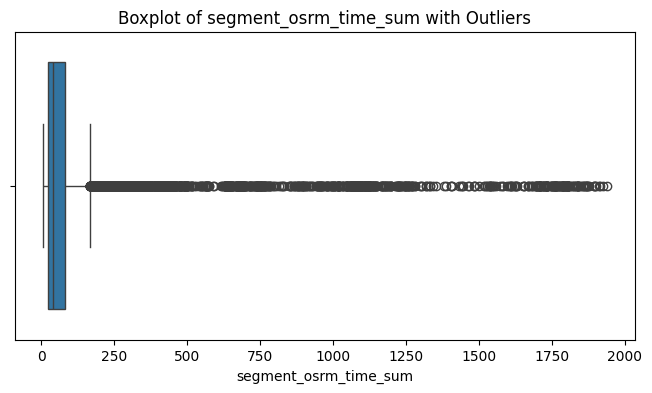

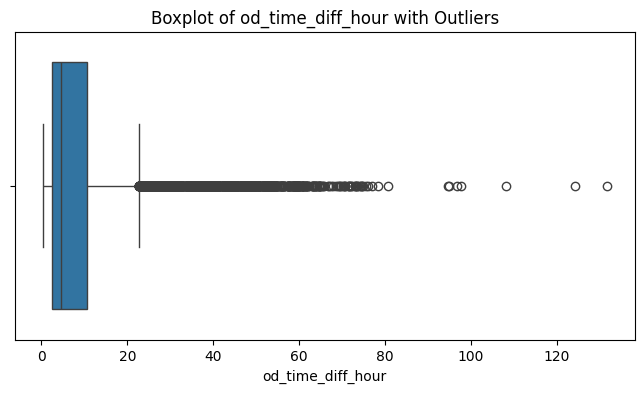

In [200]:
if outliers_count:
    print("Generating boxplots for features with outliers:")
    for col in outliers_count.keys():
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=trip_df[col])
        plt.title(f'Boxplot of {col} with Outliers')
        plt.show()
else:
    print("No outliers to visualize.")

## One-hot encoding

In [201]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_cols = trip_df.select_dtypes(include=['category']).columns.tolist()

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform categorical columns
encoded_features = ohe.fit_transform(trip_df[categorical_cols])

# Create a DataFrame from the encoded features
# Get feature names for the new columns
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)
trip_df_encoded_ohe = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=trip_df.index)

# Drop original categorical columns from trip_df and concatenate with encoded features
trip_df_numerical = trip_df.select_dtypes(include=['float64', 'int64', 'datetime64[ns]'])

trip_df_encoded = pd.concat([trip_df_numerical, trip_df_encoded_ohe], axis=1)

print("One-hot encoding applied to categorical features using Scikit-learn.")
trip_df_encoded.head()


One-hot encoding applied to categorical features using Scikit-learn.


,trip_creation_time,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum,od_time_diff_hour,data_test,data_training,route_type_Carting,route_type_FTL
trip_uuid,,,,,,,,,,,,,,,,,,,
trip-153671041653548748,2018-09-12 00:00:16.535741,440,440.973689,830.0,388.0,544.8027,2.139175,1548.0,1008.0,1320.4733,7.333333,820.0,649.8528,474.0,37.668497,0.0,1.0,0.0,1.0
trip-153671042288605164,2018-09-12 00:00:22.886430,48,48.542890,96.0,42.0,56.9116,2.285714,141.0,65.0,84.1894,6.666667,95.0,55.9899,39.0,3.026865,0.0,1.0,1.0,0.0
trip-153671043369099517,2018-09-12 00:00:33.691250,1689,1689.964663,2736.0,1528.0,2072.8556,1.790576,3308.0,1941.0,2545.2678,1.615385,2700.0,2227.5270,1710.0,65.572709,0.0,1.0,0.0,1.0
trip-153671046011330457,2018-09-12 00:01:00.113710,17,17.175274,59.0,15.0,19.6800,3.933333,59.0,16.0,19.8766,5.142857,59.0,19.8766,16.0,1.674916,0.0,1.0,1.0,0.0
trip-153671052974046625,2018-09-12 00:02:09.740725,26,26.600536,63.0,27.0,29.5696,2.333333,340.0,115.0,146.7919,5.800000,63.0,29.5697,26.0,11.972484,0.0,1.0,0.0,1.0


##Normalize/ Standardize the numerical features

In [202]:
from sklearn.preprocessing import MinMaxScaler

# Select numerical columns for scaling, excluding datetime columns
numerical_cols_to_scale = trip_df_encoded.select_dtypes(include=['float64', 'int64']).columns

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMaxScaler to the selected numerical columns
trip_df_scaled_numerical = scaler.fit_transform(trip_df_encoded[numerical_cols_to_scale])

# Create a DataFrame from the scaled numerical features
trip_df_scaled_numerical = pd.DataFrame(trip_df_scaled_numerical, columns=numerical_cols_to_scale, index=trip_df_encoded.index)

# Drop original numerical columns from trip_df_encoded and concatenate with scaled numerical features
# First, get non-numerical columns (including datetime and one-hot encoded features)
non_numerical_cols = trip_df_encoded.select_dtypes(exclude=['float64', 'int64']).columns
trip_df_preprocessed = pd.concat([trip_df_encoded[non_numerical_cols], trip_df_scaled_numerical], axis=1)

print("Numerical features have been scaled using MinMaxScaler.")
print("Head of the preprocessed DataFrame:")
trip_df_preprocessed.head()

Numerical features have been scaled using MinMaxScaler.
Head of the preprocessed DataFrame:


,trip_creation_time,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum,od_time_diff_hour,data_test,data_training,route_type_Carting,route_type_FTL
trip_uuid,,,,,,,,,,,,,,,,,,,
trip-153671041653548748,2018-09-12 00:00:16.535741,0.224713,0.225167,0.181517,0.227381,0.231204,0.022490,0.247388,0.391712,0.373134,0.014486,0.180423,0.243471,0.242236,0.284016,0.0,1.0,0.0,1.0
trip-153671042288605164,2018-09-12 00:00:22.886430,0.020334,0.020611,0.019235,0.021429,0.020646,0.024394,0.021218,0.023065,0.021373,0.013328,0.019132,0.017827,0.017081,0.020082,0.0,1.0,1.0,0.0
trip-153671043369099517,2018-09-12 00:00:33.691250,0.875912,0.876211,0.602918,0.905952,0.890665,0.017962,0.530301,0.756450,0.721625,0.004547,0.598665,0.842925,0.881988,0.496617,0.0,1.0,0.0,1.0
trip-153671046011330457,2018-09-12 00:01:00.113710,0.004171,0.004260,0.011055,0.005357,0.004578,0.045797,0.008037,0.003909,0.003074,0.010679,0.011123,0.004105,0.005176,0.009782,0.0,1.0,1.0,0.0
trip-153671052974046625,2018-09-12 00:02:09.740725,0.008863,0.009173,0.011939,0.012500,0.008846,0.025012,0.053207,0.042611,0.039185,0.011821,0.012013,0.007788,0.010352,0.088239,0.0,1.0,0.0,1.0


#Hypothesis Testing

###`actual_time` vs `osrm_time`


We want to test if there is a significant difference between the aggregated `actual_time` and `osrm_time` at the trip level. Since these two measurements are taken for the same trips (paired samples), a paired sample t-test is the most suitable statistical test.

**Hypotheses**:
*   **Null Hypothesis (H0)**: There is no significant difference between the mean aggregated `actual_time` and the mean aggregated `osrm_time`.
    
*   **Alternative Hypothesis (H1)**: There is a significant difference between the mean aggregated `actual_time` and the mean aggregated `osrm_time`.
   
We will use a significance level (alpha) of 0.05. If the p-value from the t-test is less than alpha, we reject the null hypothesis.

In [203]:
from scipy import stats

# Extract the aggregated actual_time and osrm_time from trip_df
actual_time_aggregated = segment_df['actual_time']
osrm_time_aggregated = segment_df['osrm_time']

# Perform the paired sample t-test
t_statistic, p_value = stats.ttest_rel(actual_time_aggregated, osrm_time_aggregated)

print(f"Paired Sample T-Test Results:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")



Paired Sample T-Test Results:
T-statistic: 82.4970
P-value: 0.0000


In [204]:
# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference between the mean aggregated actual_time and osrm_time.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference between the mean aggregated actual_time and osrm_time.")


Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference between the mean aggregated actual_time and osrm_time.


### `actual_time` vs `segment_actual_time`

We want to test if there is a significant difference between the aggregated `actual_time` and `segment_actual_time` at the trip level. Similar to the previous comparison, a paired sample t-test is the most suitable statistical test for these related measurements.

**Hypotheses**:
*   **Null Hypothesis (H0)**: There is no significant difference between the mean aggregated `actual_time` and the mean aggregated `segment_actual_time`.
    
*   **Alternative Hypothesis (H1)**: There is a significant difference between the mean aggregated `actual_time` and the mean aggregated `segment_actual_time`.
   

We will use a significance level (alpha) of 0.05. If the p-value from the t-test is less than alpha, we reject the null hypothesis.

In [205]:
from scipy import stats

# Extract the aggregated actual_time and segment_actual_time from trip_df
actual_time_aggregated = segment_df['actual_time']
segment_actual_time_aggregated = segment_df['segment_actual_time']

# Perform the paired sample t-test
t_statistic, p_value = stats.ttest_rel(actual_time_aggregated, segment_actual_time_aggregated)

print(f"Paired Sample T-Test Results:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")


Paired Sample T-Test Results:
T-statistic: 73.4538
P-value: 0.0000


In [206]:
# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference between the mean aggregated actual_time and segment_actual_time.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference between the mean aggregated actual_time and segment_actual_time.")


Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference between the mean aggregated actual_time and segment_actual_time.


### `OSRM distance` vs `segment OSRM distance`

We want to test if there is a significant difference between the aggregated `OSRM distance` and `segment OSRM distance` at the trip level. Similar to the previous comparison, a paired sample t-test is the most suitable statistical test for these related measurements.

**Hypotheses**:
*   **Null Hypothesis (H0)**: There is no significant difference between the mean aggregated `OSRM distance` and the mean aggregated `segment OSRM distance`.
    
*   **Alternative Hypothesis (H1)**: There is a significant difference between the mean aggregated `OSRM distance` and the mean aggregated `segment OSRM distance`.
   

We will use a significance level (alpha) of 0.05. If the p-value from the t-test is less than alpha, we reject the null hypothesis.

In [207]:
# Extract the aggregated osrm_distance and segment_osrm_distance from trip_df
osrm_distance_aggregated = segment_df['osrm_distance']
segment_osrm_distance_aggregated = segment_df['segment_osrm_distance']

# Perform the paired sample t-test
t_statistic, p_value = stats.ttest_rel(osrm_distance_aggregated, segment_osrm_distance_aggregated)

print(f"Paired Sample T-Test Results:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")


Paired Sample T-Test Results:
T-statistic: -39.7489
P-value: 0.0000


In [208]:
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference between the mean aggregated osrm_distance and segment_osrm_distance.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference between the mean aggregated osrm_distance and segment_osrm_distance.")


Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference between the mean aggregated osrm_distance and segment_osrm_distance.


### `osrm_time` vs `segment_osrm_time`

We want to test if there is a significant difference between the aggregated `osrm_time` and `segment_osrm_time` at the trip level. Since these two measurements are taken for the same trips (paired samples), a paired sample t-test is the most suitable statistical test for these related measurements.

**Hypotheses**:
*   **Null Hypothesis (H0)**: There is no significant difference between the mean aggregated `osrm_time` and the mean aggregated `segment_osrm_time`.
    
*   **Alternative Hypothesis (H1)**: There is a significant difference between the mean aggregated `osrm_time` and the mean aggregated `segment_osrm_time`.
    

We will use a significance level (alpha) of 0.05. If the p-value from the t-test is less than alpha, we reject the null hypothesis.

In [209]:
from scipy import stats

# Extract the aggregated osrm_time and segment_osrm_time from trip_df
osrm_time_aggregated = trip_df['osrm_time']
segment_osrm_time_aggregated = trip_df['segment_osrm_time']

# Perform the paired sample t-test
t_statistic, p_value = stats.ttest_rel(osrm_time_aggregated, segment_osrm_time_aggregated)

print(f"Paired Sample T-Test Results:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")



Paired Sample T-Test Results:
T-statistic: -55.1588
P-value: 0.0000


In [210]:
# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference between the mean aggregated osrm_time and segment_osrm_time.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference between the mean aggregated osrm_time and segment_osrm_time.")


Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference between the mean aggregated osrm_time and segment_osrm_time.


#Visual Analysis

###`actual_time` vs `osrm_time`

/tmp/ipython-input-881733663.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


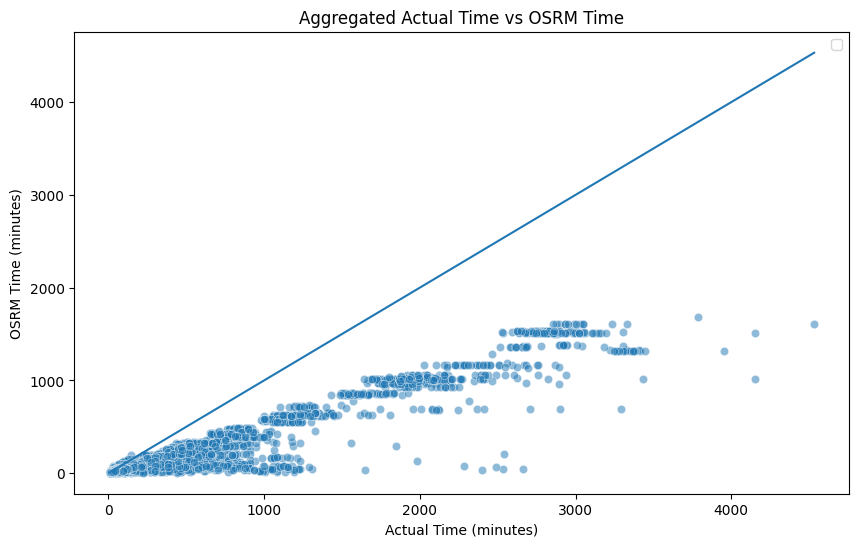

In [211]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=trip_df['actual_time'], y=trip_df['osrm_time'], alpha=0.5)
plt.plot([trip_df['actual_time'].min(), trip_df['actual_time'].max()],
         [trip_df['actual_time'].min(), trip_df['actual_time'].max()])
plt.title('Aggregated Actual Time vs OSRM Time')
plt.xlabel('Actual Time (minutes)')
plt.ylabel('OSRM Time (minutes)')
plt.legend()
plt.show()

### `actual_time` vs `segment_actual_time`


/tmp/ipython-input-3155360406.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


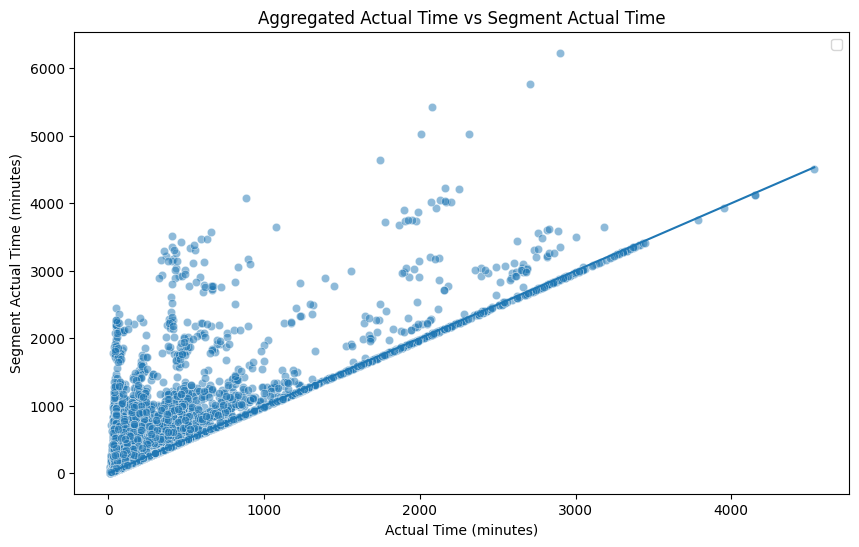

In [213]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=trip_df['actual_time'], y=trip_df['segment_actual_time'], alpha=0.5)
plt.plot([trip_df['actual_time'].min(), trip_df['actual_time'].max()],
         [trip_df['actual_time'].min(), trip_df['actual_time'].max()])
plt.title('Aggregated Actual Time vs Segment Actual Time')
plt.xlabel('Actual Time (minutes)')
plt.ylabel('Segment Actual Time (minutes)')
plt.legend()
plt.show()

### `OSRM distance` vs `segment OSRM distance`

/tmp/ipython-input-2640134418.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


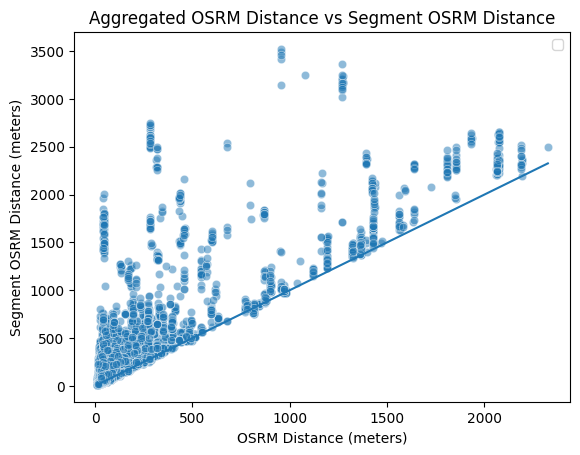

In [214]:
plt.figure()
sns.scatterplot(x=trip_df['osrm_distance'], y=trip_df['segment_osrm_distance'], alpha=0.5)
plt.plot([trip_df['osrm_distance'].min(), trip_df['osrm_distance'].max()],
         [trip_df['osrm_distance'].min(), trip_df['osrm_distance'].max()])
plt.title('Aggregated OSRM Distance vs Segment OSRM Distance')
plt.xlabel('OSRM Distance (meters)')
plt.ylabel('Segment OSRM Distance (meters)')
plt.legend()
plt.show()

### `osrm_time` vs `segment_osrm_time`

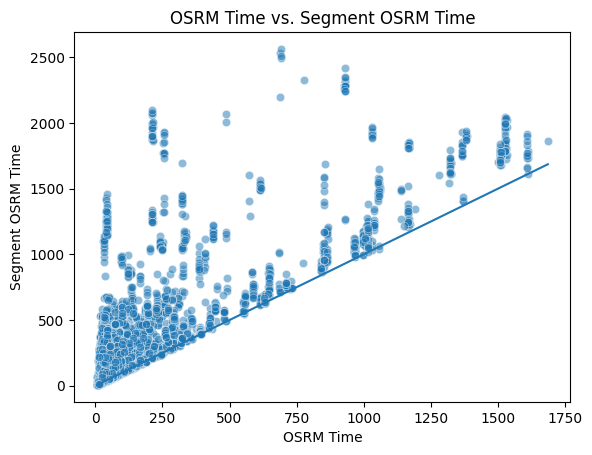

In [216]:
plt.figure()
sns.scatterplot(x=trip_df['osrm_time'], y=trip_df['segment_osrm_time'], alpha=0.5)
plt.plot([trip_df['osrm_time'].min(), trip_df['osrm_time'].max()],
         [trip_df['osrm_time'].min(), trip_df['osrm_time'].max()])
plt.xlabel('OSRM Time')
plt.ylabel('Segment OSRM Time')
plt.title('OSRM Time vs. Segment OSRM Time')
plt.show()

#Business Insights and recommendations

In [222]:
top_10_corridors = trip_df['corridor'].value_counts().nlargest(10)
print("Top 10 busiest corridors identified:")
print(top_10_corridors)

Top 10 busiest corridors identified:
corridor
Bengaluru_Bengaluru    581
Bangalore_Bengaluru    455
Hyderabad_Hyderabad    355
Mumbai_Mumbai          339
Bhiwandi_Mumbai        332
Bengaluru_Bangalore    328
Gurgaon_Delhi          241
Mumbai Hub_Mumbai      227
Chennai_Chennai        223
Mumbai_Bhiwandi        207
Name: count, dtype: int64



To calculate the average actual distance and average actual time for the top 10 busiest corridors, I need to filter the original `trip_df` DataFrame to include only the trips belonging to these corridors. Then, I will group the filtered data by 'corridor' and calculate the mean of 'actual_distance_to_destination' and 'actual_time'.



In [223]:
top_corridors_list = top_10_corridors.index.tolist()

# Filter trip_df to include only trips from the top 10 busiest corridors
filtered_corridors_df = trip_df[trip_df['corridor'].isin(top_corridors_list)]

# Group by corridor and calculate the average actual_distance and actual_time
average_metrics_top_corridors = filtered_corridors_df.groupby('corridor')[['actual_distance_to_destination', 'actual_time']].mean()

print("Average actual distance and actual time for the top 10 busiest corridors:")
print(average_metrics_top_corridors)

Average actual distance and actual time for the top 10 busiest corridors:
                     actual_distance_to_destination  actual_time
corridor                                                        
Bangalore_Bengaluru                       27.056047    77.720879
Bengaluru_Bangalore                       28.507326    93.716463
Bengaluru_Bengaluru                       34.708816    89.488812
Bhiwandi_Mumbai                           23.004948    78.391566
Chennai_Chennai                           23.706689    64.044843
Gurgaon_Delhi                             47.319363   123.721992
Hyderabad_Hyderabad                       34.338922   116.163380
Mumbai Hub_Mumbai                         16.341615    56.938326
Mumbai_Bhiwandi                           21.589225    94.516908
Mumbai_Mumbai                             13.966211    63.625369


In [224]:
top_destination_states = trip_df['destination_state'].value_counts().nlargest(10)
print("Top 10 Destination States Identified:")
print(top_destination_states)

Top 10 Destination States Identified:
destination_state
Maharashtra      2561
Karnataka        2294
Haryana          1640
Tamil Nadu       1084
Uttar Pradesh     805
Telangana         784
Gujarat           734
West Bengal       697
Delhi             657
Punjab            617
Name: count, dtype: int64


## Business Recommendations

Based on the analysis of busiest city-to-city corridors and top source/destination states, here are some business recommendations focused on operational efficiency, resource allocation, and strategic planning:

### Key Findings Summary:

**Top 10 Busiest Corridors (City-to-City):**
```
Bengaluru_Bengaluru    581 trips
Bangalore_Bengaluru    455 trips
Hyderabad_Hyderabad    355 trips
Mumbai_Mumbai          339 trips
Bhiwandi_Mumbai        332 trips
Bengaluru_Bangalore    328 trips
Gurgaon_Delhi          241 trips
Mumbai Hub_Mumbai      227 trips
Chennai_Chennai        223 trips
Mumbai_Bhiwandi        207 trips
```

**Average Actual Distance and Time for Top Corridors:**
```
                     actual_distance_to_destination  actual_time
corridor                                                        
Bangalore_Bengaluru                       27.06              77.72
Bengaluru_Bangalore                       28.51              93.72
Bengaluru_Bengaluru                       34.71              89.49
Bhiwandi_Mumbai                           23.00              78.39
Chennai_Chennai                           23.71              64.04
Gurgaon_Delhi                             47.32             123.72
Hyderabad_Hyderabad                       34.34             116.16
Mumbai Hub_Mumbai                         16.34              56.94
Mumbai_Bhiwandi                           21.59              94.52
Mumbai_Mumbai                             13.97              63.63
```

**Top 10 Source States:**
```
Maharashtra      2714 trips
Karnataka        2143 trips
Haryana          1823 trips
Tamil Nadu       1039 trips
Telangana         784 trips
Uttar Pradesh     760 trips
Gujarat           750 trips
Delhi             725 trips
West Bengal       665 trips
Punjab            536 trips
```

**Top 10 Destination States:**
```
Maharashtra      2561 trips
Karnataka        2294 trips
Haryana          1640 trips
Tamil Nadu       1084 trips
Uttar Pradesh     805 trips
Telangana         784 trips
Gujarat           734 trips
West Bengal       697 trips
Delhi             657 trips
Punjab            617 trips
```

### Recommendations:

1.  **Optimize High-Traffic Corridors:**
    *   **Focus on Bengaluru-Bengaluru, Bangalore-Bengaluru, Hyderabad-Hyderabad, and Mumbai-Mumbai corridors:** These are the busiest internal city routes. Invest in optimizing local delivery networks, potentially through dedicated urban hubs or micro-fulfillment centers, to reduce intra-city travel times and distances. Implement advanced route optimization software for these routes.
    *   **Address Gurgaon-Delhi corridor:** This route has the highest average actual distance and time among the top 10. This indicates potential for significant improvement. Investigate traffic patterns, road conditions, and explore alternative routing strategies or dedicated freight lanes during peak hours.

2.  **Strategic Resource Allocation:**
    *   **Fleet Management:** Allocate a larger proportion of the fleet, especially smaller, agile vehicles for intra-city deliveries, to the major metropolitan areas identified (Bengaluru, Mumbai, Hyderabad, Chennai, Delhi). For longer routes like Gurgaon-Delhi, ensure availability of larger, more efficient trucks.
    *   **Staffing:** Ensure adequate staffing at hubs and during peak hours for loading/unloading and dispatch in the top source and destination states (Maharashtra, Karnataka, Haryana). This is crucial to prevent delays in high-volume regions.
    *   **Infrastructure Investment:** Consider establishing additional cross-docking facilities or transit points in high-volume states like Maharashtra, Karnataka, and Haryana to streamline package flow and reduce transit times.

3.  **Operational Efficiency Improvements:**
    *   **Route Planning Enhancement:** Leverage predictive analytics to anticipate demand and optimize routes proactively for the top corridors. This can help in dynamically adjusting routes based on real-time traffic and weather conditions.
    *   **Load Consolidation:** For corridors with consistently high volume, explore opportunities for load consolidation to maximize vehicle utilization and reduce the number of trips, thereby saving fuel and operational costs.
    *   **Performance Monitoring:** Continuously monitor the actual vs. OSRM times and distances for the busiest corridors. Investigate significant discrepancies to identify bottlenecks, improve route planning algorithms, or address on-ground operational issues.

4.  **Customer Satisfaction & Service Level Agreements (SLAs):**
    *   By optimizing the busiest corridors, delivery times can be significantly improved, leading to higher customer satisfaction. Re-evaluate and potentially offer more competitive SLAs for these optimized routes.
    *   Proactive communication with customers regarding potential delays, especially on challenging routes, can mitigate negative experiences.

By implementing these recommendations, the company can enhance its logistical operations, reduce costs, and improve service delivery across its most critical corridors and regions.